<a target="_blank" href="https://colab.research.google.com/github/pleyad/Summer-School-2026/blob/main/notebooks/02_quality_assurance.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a> ersetzen mit final gültigem Link

## Housekeeping

In [1]:
%pip install "impresso_pipelines[ocrqa]"

/home/bode-wsl/projects/summerschool26/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


❗ Please restart the kernel/runtime after installing the package to ensure that all changes take effect.

In [2]:
import os
import random
import time
import requests
from pathlib import Path

from impresso_pipelines.ocrqa import OCRQAPipeline
import pandas as pd
from tqdm.notebook import tqdm

In [3]:
IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ
DATA_DIR = Path('/content/drive/MyDrive/ZBSummerSchool26/data') if IN_COLAB else Path('../data')

## Setup (Interaction required)

## Load the data

### <img src="https://cdn.simpleicons.org/googledrive" alt="💾" width=16> Load your own data from Google Drive

### <img src="https://cdn.svglogos.dev/logos/google-drive.svg" alt="💾" width=16> Load your own data from Google Drive

In [4]:
### ⬇️⬇️⬇️ 💽 Adjust here if you want to load the data from your google drive
CORPUS_NAME = "armensteuer_and_similars"
LOAD_OWN_DATA = True
### ⬆️⬆️⬆️

In [5]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    os.makedirs(DATA_DIR, exist_ok=True)

In [28]:
if LOAD_OWN_DATA:
    RAWDATA_PATH = DATA_DIR / f"{CORPUS_NAME}.raw.csv" 
    raw_df = pd.read_csv(RAWDATA_PATH, index_col="id")
    # RAWDATA_PATH = DATA_DIR / f"{CORPUS_NAME}.raw.parquet" 
    # raw_df = pd.read_parquet(RAWDATA_PATH)

### <img src="https://cdn.simpleicons.org/github" alt="🏫" width=16> Load from Github

### <img src="https://www.zb.uzh.ch/themes/zb/assets/images/favicon-192.png" alt="💾" width=16> Load from example

In [29]:
if not LOAD_OWN_DATA:
    RAWDATA_ORIGIN_URL = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armensteuer_and_similars.raw.csv"
    raw_df = pd.read_csv(RAWDATA_ORIGIN_URL, index_col="id")

    #RAWDATA_ORIGIN_URL = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armensteuer_and_similars.01.parquet" 
    #raw_df = pd.read_parquet(RAWDATA_ORIGIN_URL)

## Preparing the data

In [30]:
raw_df["year"] = pd.to_datetime(raw_df["date"]).dt.year

## Quality Assessment

In [31]:
ocrqa_pipeline = OCRQAPipeline()

In [32]:
def assess_quality(s: str) -> float:
    quality_object = ocrqa_pipeline(s, language="de")
    return quality_object["score"]

tqdm.pandas(desc="Assessing OCR quality")
raw_df["ocr_quality"] = raw_df["content"].progress_apply(assess_quality)

Assessing OCR quality:   0%|          | 0/4044 [00:00<?, ?it/s]

## Inspect the results

### OCR Quality Distribution over time

In [40]:
import numpy as np

# Define number of tiers
N = 10
bins = np.linspace(0, 1, N + 1)
tier_labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(N)]

raw_df["quality_tier"] = pd.cut(
    raw_df["ocr_quality"],
    bins=bins.tolist(),
    labels=tier_labels,
    include_lowest=True
)

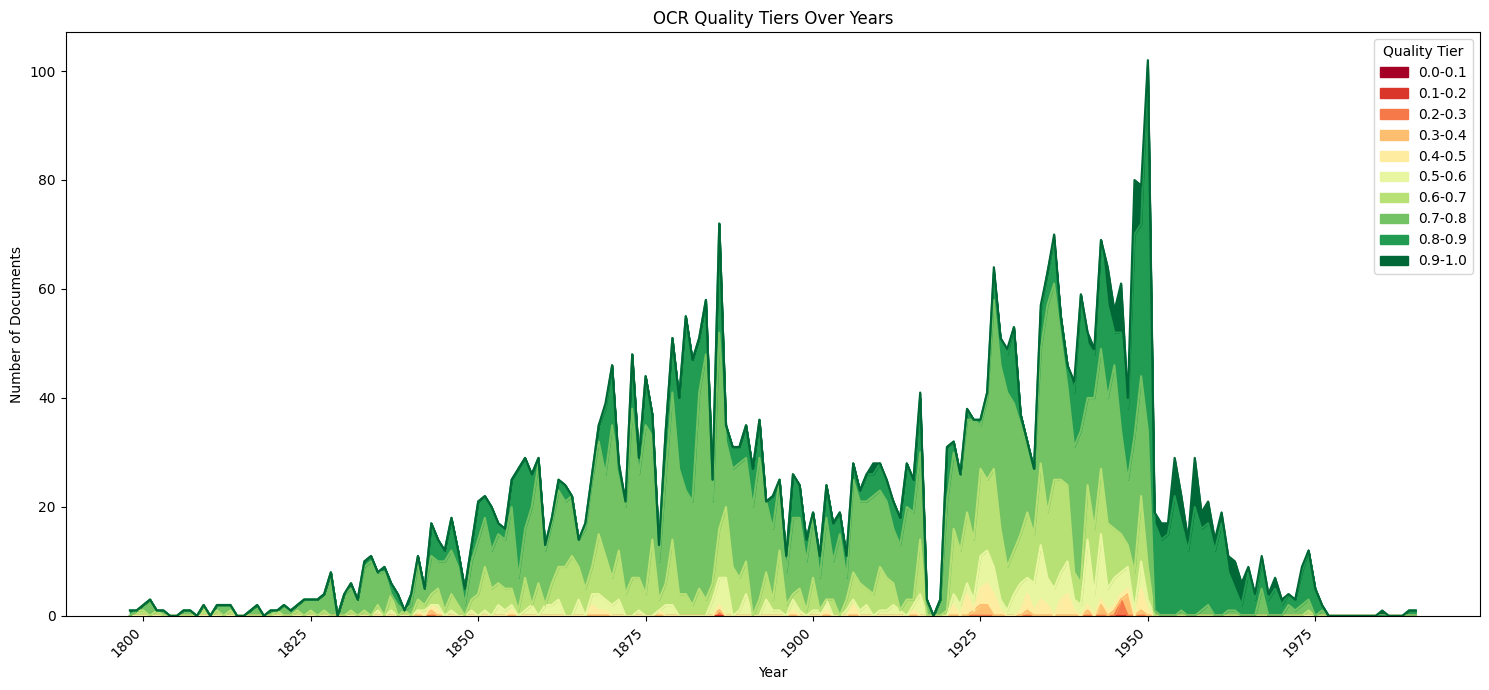

In [41]:
import matplotlib.pyplot as plt

def plot_quality_tiers_over_time(df: pd.DataFrame):
    df = df.copy()

    # Group by year and quality tier, then count occurrences
    df_grouped = df.groupby(['year', 'quality_tier'], observed=False).size().unstack(fill_value=0)
    full_index = range(df_grouped.index.min(), df_grouped.index.max() + 1)
    df_grouped = df_grouped.reindex(full_index, fill_value=0)

    cmap = plt.cm.RdYlGn
    colors = {label: cmap(i / (N - 1)) for i, label in enumerate(tier_labels)}

    # Plot the stacked bar chart
    ax = df_grouped.plot(kind='area', stacked=True, figsize=(15, 7),
                            color=[colors[col] for col in df_grouped.columns]
    )

    # Add title and labels
    plt.title('OCR Quality Tiers Over Years')
    plt.xlabel('Year')
    plt.ylabel('Number of Documents')
    plt.legend(title='Quality Tier')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_quality_tiers_over_time(raw_df)

In [42]:
unique_quality_tiers = raw_df['quality_tier'].unique()

for tier in sorted(unique_quality_tiers):
    # Filter the DataFrame for the current tier
    tier_df = raw_df[raw_df['quality_tier'] == tier]

    # Select a random example from the filtered DataFrame
    if not tier_df.empty:
        example = tier_df.sample(1).iloc[0]
        print(f"OCR Quality Score: {example['ocr_quality']:.2f}")
        print(f"{example['content'][:500]}...") # Truncate content for display
        print()

OCR Quality Score: 0.25
Mittwoch. 25. April 19 « Vlatt Neue Zürcher Zeitung « Morgenausgabe Vr.? 08 Wirtschafts- und sozialpolitische Ideen in der Schweiz ri. Tir Piilmirfliiiin unb rjprfbilbniifl roirtfcfKirtS « linb fo,; inlpolitifd) rr fibern, jene » Teufen s ber 9J! rii. fcfjrii, 6fll um bir jWttfni8fri (| ftc ober. flrrrditefte " © r. [{ditting her loictf d) aft tidjcii iiiiP filialen £ vbniiiiiirn bemüht lit, Wirb niiiiiTimlti l & ttl, t ', iiinnimrnl)<; iii., ir * mit brill allgemeinen poütiirii-üfnnomifdi-fpaif...

OCR Quality Score: 0.39
Dlenstnz 25. November 1924 Vlatt Vlorgenansaabe. Abonnements- Einladung. Auf dl « täglich dl « im «! erscheinend « Neue Zürcher Zeitung und schweizerisches Handelsblatt lann b «! « amtlichen schweizerischen Vosl- »»»« aus je aul 2nb « eines Monats oder 2u « lstals abonnier! werden. Auch von leiten un >; erei Verträgerinnen und Ablagestellen sowie uon unserer lfUlal « Bahnhofstraße 6 « weiden leder, zeit Bestellungen « ntf,« gengenomme ». Pro D

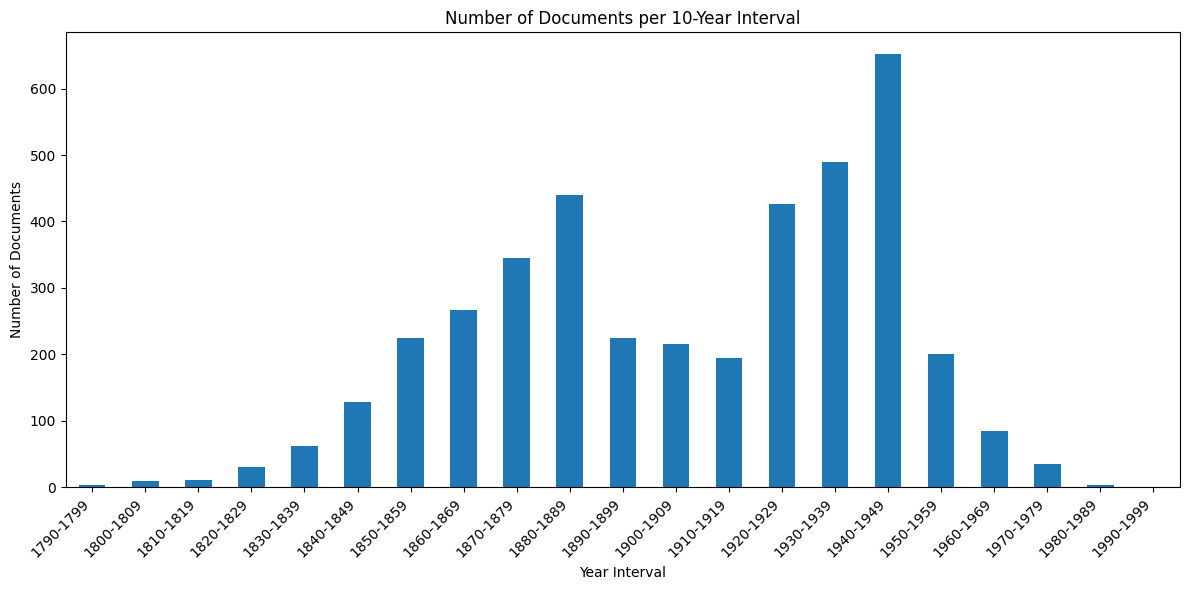

In [43]:
def plot_documents_per_year_intervals(df: pd.DataFrame, n_years: int):

    df = df.copy()
    start = (df["year"].min() // n_years) * n_years
    end = (df["year"].max() // n_years + 1) * n_years

    # Include the final bin edge so the newest interval is not dropped.
    bins = range(start, end + 1, n_years)
    labels = [f"{b}-{b+n_years-1}" for b in bins[:-1]]
    df["year_interval"] = pd.cut(df["year"], bins=bins, labels=labels, include_lowest=True)

    # Create bar plot
    plt.figure(figsize=(12, 6))
    df.groupby("year_interval", observed=False).size().plot(kind='bar')
    plt.title(f'Number of Documents per {n_years}-Year Interval')
    plt.xlabel('Year Interval')
    plt.ylabel('Number of Documents')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_documents_per_year_intervals(raw_df, n_years=10)

## Filter Corpus

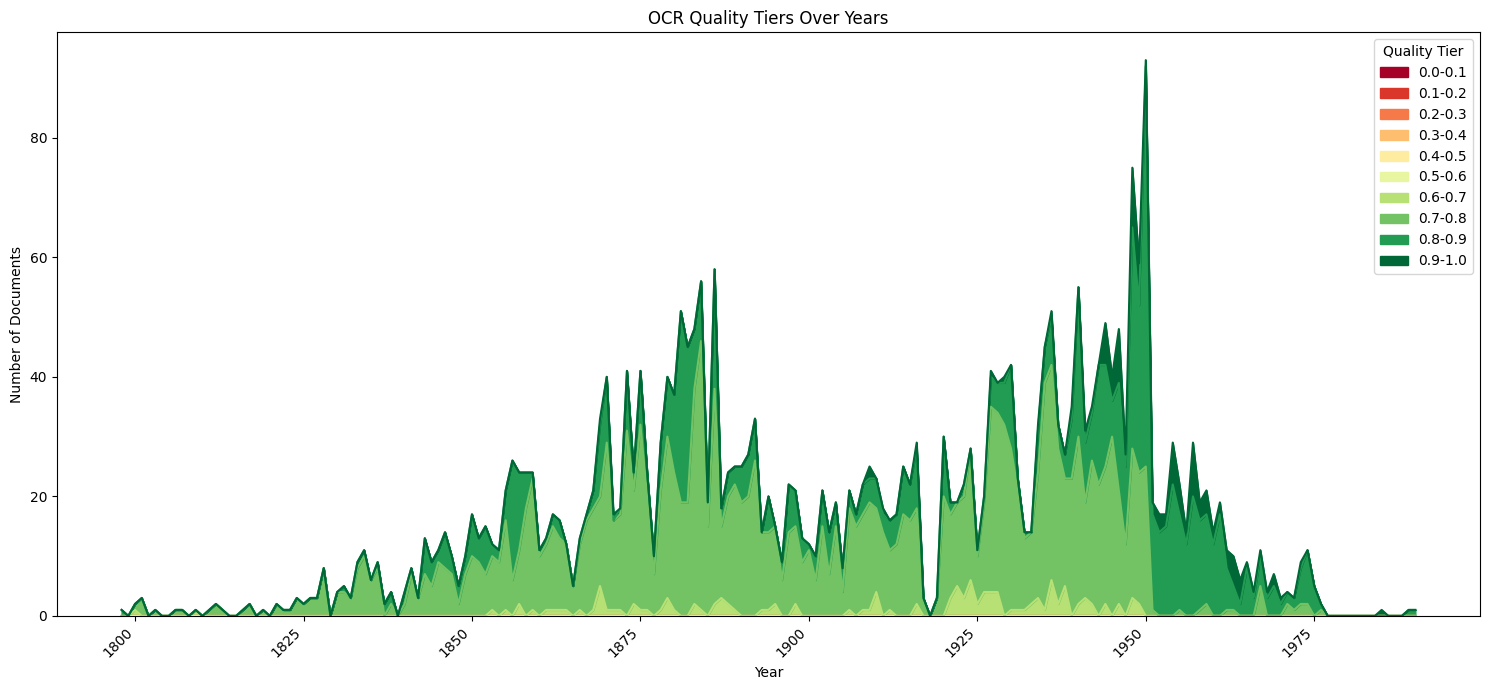

In [44]:
QUALITY_CUTOFF = 0.7

df_filtered = raw_df[raw_df["ocr_quality"] >= QUALITY_CUTOFF]

plot_quality_tiers_over_time(df_filtered)

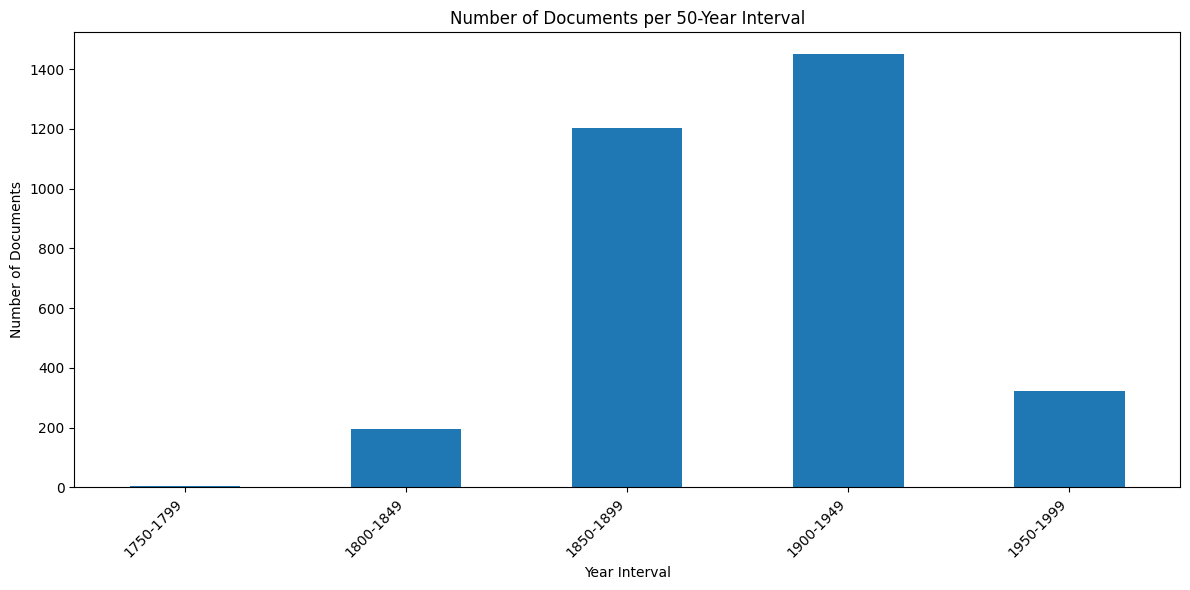

In [45]:
plot_documents_per_year_intervals(df_filtered, n_years=50)

In [46]:
if LOAD_OWN_DATA:
    df_filtered.to_csv(DATA_DIR / f"{CORPUS_NAME}.filtered.csv", index=True)